# Fine-tuning de LFM2.5-VL-450M con Unsloth — end to end

Notebook completo para fine-tunear el VLM compacto **LFM2.5-VL-450M** sobre nuestro dataset clonado `damianGil/wildfire-prevention` (clasificación de riesgo de incendios desde imágenes Sentinel-2 RGB + SWIR a JSON estructurado de 6 campos).

**Pre-requisitos:**
- Unsloth instalado (Linux / WSL2 / Colab; en Windows nativo puede dar problemas con `bitsandbytes` y `triton`).
- GPU NVIDIA con ≥6 GB VRAM (RTX 3060 12 GB es suficiente).
- `HF_TOKEN` con permisos write en `code/wildfire-prevention/.env`.

**Roadmap end-to-end:**
1. Setup (imports + .env)
2. Descargar el dataset desde HF
3. Inspección de una muestra (RGB + SWIR + ground truth)
4. Generar JSONL (formato leap-finetune, **opcional/legacy**)
5. Verificación del JSONL
6. Cargar el modelo LFM2.5-VL-450M con `FastVisionModel`
7. Configurar LoRA adapters
8. **Inferencia ANTES** de entrenar (baseline)
9. Preparar el dataset en formato Unsloth (PIL Images en memoria) + Entrenar
10. **Inferencia DESPUÉS** de entrenar + eval rápida por campo
11. Guardar el modelo (LoRA local + push opcional a HF)
12. (Opcional) Convertir a GGUF para inferencia con llama.cpp

## 1. Setup

In [1]:
import os
import json
from pathlib import Path

from dotenv import load_dotenv
load_dotenv()

assert os.environ.get("HF_TOKEN", "").startswith("hf_"), \
    "No se ha cargado HF_TOKEN. Revisa que .env existe y tiene la línea HF_TOKEN=hf_..."


assert os.environ.get("COMET_API_KEY"), "Falta COMET_API_KEY en .env"
print("HF_TOKEN y COMET_API_KEY cargados.")

print("HF_TOKEN cargado correctamente.")

HF_TOKEN y COMET_API_KEY cargados.
HF_TOKEN cargado correctamente.


## 2. Descargar el dataset

In [2]:
from huggingface_hub import snapshot_download

HF_DATASET = "damianGil/wildfire-prevention"

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_DIR / "data" / "wildfire"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_DIR = {PROJECT_DIR}")
print(f"DATA_DIR    = {DATA_DIR}\n")

print(f"Descargando {HF_DATASET} -> {DATA_DIR} ...")
snapshot_download(
    repo_id=HF_DATASET,
    repo_type="dataset",
    local_dir=str(DATA_DIR),
)
print("Descarga completada.\n")

print("Contenido descargado:")
for item in sorted(DATA_DIR.iterdir()):
    if item.is_dir():
        n = sum(1 for _ in item.iterdir())
        print(f"  {item.name}/  ({n} archivos)")
    else:
        print(f"  {item.name}  ({item.stat().st_size:,} bytes)")

/home/damian/unsloth-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_DIR = /mnt/c/Users/Usuario/Documents/GitHub/finetunning-library/code/wildfire-prevention
DATA_DIR    = /mnt/c/Users/Usuario/Documents/GitHub/finetunning-library/code/wildfire-prevention/data/wildfire

Descargando damianGil/wildfire-prevention -> /mnt/c/Users/Usuario/Documents/GitHub/finetunning-library/code/wildfire-prevention/data/wildfire ...


Fetching ... files: 2084it [00:08, 243.77it/s]

Descarga completada.

Contenido descargado:
  .cache/  (1 archivos)
  .gitattributes  (2,504 bytes)
  README.md  (549 bytes)
  data/  (2 archivos)
  images/  (2080 archivos)
  wildfire_test.jsonl  (254,654 bytes)
  wildfire_train.jsonl  (1,276,317 bytes)


## 3. Inspección de una muestra

Splits disponibles: ['train', 'test']
  Train: 862 muestras
  Test:  172 muestras

=== Muestra #0 ===
Región:    angeles_nf_ca
Timestamp: 2024-01-31T10:00:00+00:00
Split:     train
RGB path:  images/angeles_nf_ca_s01_t00_rgb.png
SWIR path: images/angeles_nf_ca_s01_t00_swir.png

>>> Ground truth (lo que el modelo debe aprender a generar):
{
  "risk_level": "medium",
  "dry_vegetation_present": true,
  "urban_interface": false,
  "steep_terrain": true,
  "water_body_present": true,
  "image_quality_limited": false
}

>>> RGB (color natural — terreno, urbano, agua):


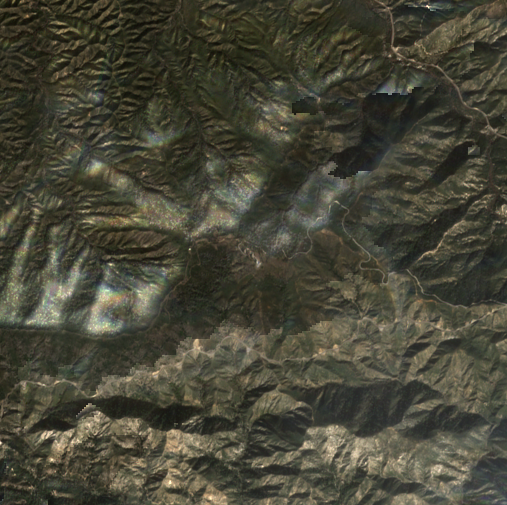


>>> SWIR (infrarrojo — vegetación seca = naranja/rojo):


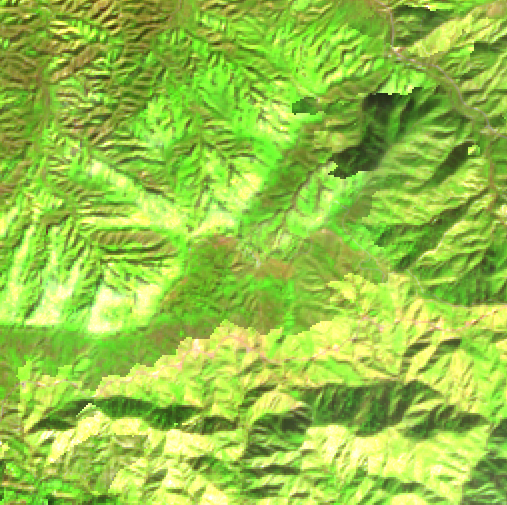

In [3]:
from datasets import load_dataset
from PIL import Image
from IPython.display import display

ds = load_dataset(str(DATA_DIR))
print(f"Splits disponibles: {list(ds.keys())}")
print(f"  Train: {len(ds['train'])} muestras")
print(f"  Test:  {len(ds['test'])} muestras\n")

SAMPLE_IDX = 0
sample = ds["train"][SAMPLE_IDX]

print(f"=== Muestra #{SAMPLE_IDX} ===")
print(f"Región:    {sample['region']}")
print(f"Timestamp: {sample['timestamp']}")
print(f"Split:     {sample['split']}")
print(f"RGB path:  {sample['rgb_path']}")
print(f"SWIR path: {sample['swir_path']}")

output_dict = json.loads(sample['output'])
print(f"\n>>> Ground truth (lo que el modelo debe aprender a generar):")
print(json.dumps(output_dict, indent=2))

rgb_full  = DATA_DIR / sample['rgb_path']
swir_full = DATA_DIR / sample['swir_path']

print(f"\n>>> RGB (color natural — terreno, urbano, agua):")
display(Image.open(rgb_full))
print(f"\n>>> SWIR (infrarrojo — vegetación seca = naranja/rojo):")
display(Image.open(swir_full))

## 4. Conversión a formato JSONL VLM SFT  *(opcional / legacy)*

Este JSONL es el formato que usaría leap-finetune u otros frameworks. **Unsloth NO lo necesita** — espera PIL Images en memoria, no paths. Lo dejamos por:
1. Tener el dataset preparado por si decides usar otro framework después.
2. Servir de "sanity check" del pipeline de datos.

Si solo quieres entrenar con Unsloth, puedes saltar esta sección y la 5.

In [4]:
# Prompts del cookbook original (Liquid usó estos para etiquetar el dataset con Opus).
# IMPORTANTE: usar los MISMOS prompts en entrenamiento e inferencia.
SYSTEM_PROMPT = """\
You are a remote sensing analyst specialising in wildfire risk assessment.
You will be given two Sentinel-2 satellite images of the same land tile:
  1. RGB composite (bands B4-B3-B2): natural colour, useful for terrain, infrastructure, and land cover.
  2. SWIR composite (bands B12-B8-B4): highlights vegetation moisture stress and dryness. Healthy vegetation appears green/cyan, stressed or dry vegetation appears orange/red, bare soil appears magenta/pink, and burned areas appear dark red or black.

Assess the wildfire risk of the tile and return ONLY a valid JSON object — no markdown, no explanation outside the JSON — with exactly these fields:

{
  "risk_level": "low | medium | high",
  "dry_vegetation_present": true | false,
  "urban_interface": true | false,
  "steep_terrain": true | false,
  "water_body_present": true | false,
  "image_quality_limited": true | false
}
"""

USER_TEXT = (
    "Image 1 is the RGB composite. Image 2 is the SWIR composite. "
    "Return the wildfire risk JSON for this tile."
)

# El SYSTEM y USER van juntos en el turno user (LFM2.5-VL no soporta system separado).
PROMPT = f"{SYSTEM_PROMPT.strip()}\n\n{USER_TEXT}"


def load_conversation(image_rgb_path: str, image_swir_path: str,
                      prompt: str, ground_truth: str) -> list:
    return [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_rgb_path},
                {"type": "image", "image": image_swir_path},
                {"type": "text",  "text":  prompt},
            ],
        },
        {
            "role": "assistant",
            "content": [{"type": "text", "text": ground_truth}],
        },
    ]


def write_jsonl(rows: list[dict], path: Path) -> None:
    path.write_text("\n".join(json.dumps(r) for r in rows), encoding="utf-8")


# Genera train.jsonl + test.jsonl junto al dataset descargado
for split_name in ("train", "test"):
    rows = []
    for s in ds[split_name]:
        rgb_filename  = Path(s["rgb_path"]).name
        swir_filename = Path(s["swir_path"]).name
        conv = load_conversation(rgb_filename, swir_filename, PROMPT, s["output"])
        rows.append({"messages": conv})
    out = DATA_DIR / f"wildfire_{split_name}.jsonl"
    write_jsonl(rows, out)
    print(f"  {split_name}: {len(rows)} filas -> {out}")

print("\nJSONLs generados al lado de data/ y images/.")

  train: 862 filas -> /mnt/c/Users/Usuario/Documents/GitHub/finetunning-library/code/wildfire-prevention/data/wildfire/wildfire_train.jsonl
  test: 172 filas -> /mnt/c/Users/Usuario/Documents/GitHub/finetunning-library/code/wildfire-prevention/data/wildfire/wildfire_test.jsonl

JSONLs generados al lado de data/ y images/.


## 5. Verificación del JSONL

In [5]:
JSONL_PATH = DATA_DIR / "wildfire_train.jsonl"
IMAGES_DIR = DATA_DIR / "images"

with open(JSONL_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()
print(f"Total filas en {JSONL_PATH.name}: {len(lines)}\n")

first_row = json.loads(lines[0])
print("=== Primera fila ===")
print(f"Roles: {[m['role'] for m in first_row['messages']]}")
print(f"Types user.content: {[c['type'] for c in first_row['messages'][0]['content']]}")
print(f"Assistant output: {first_row['messages'][1]['content'][0]['text'][:150]}...\n")

# Sanity check: ¿todas las imágenes referenciadas existen?
referenced = set()
for split in ("train", "test"):
    with open(DATA_DIR / f"wildfire_{split}.jsonl", "r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            for block in row["messages"][0]["content"]:
                if block["type"] == "image":
                    referenced.add(block["image"])

on_disk = {p.name for p in IMAGES_DIR.iterdir() if p.is_file()}
missing  = referenced - on_disk
unused   = on_disk - referenced
print(f"Imágenes referenciadas: {len(referenced)}  |  en disco: {len(on_disk)}")
print(f"Faltantes (CRÍTICO si > 0): {len(missing)}")
print(f"Sin usar (no crítico):       {len(unused)}")

Total filas en wildfire_train.jsonl: 862

=== Primera fila ===
Roles: ['user', 'assistant']
Types user.content: ['image', 'image', 'text']
Assistant output: {"risk_level": "medium", "dry_vegetation_present": true, "urban_interface": false, "steep_terrain": true, "water_body_present": true, "image_quality_l...

Imágenes referenciadas: 2068  |  en disco: 2080
Faltantes (CRÍTICO si > 0): 0
Sin usar (no crítico):       12


## 6. Cargar el modelo LFM2.5-VL-450M con Unsloth

Si no tienes Unsloth instalado, ejecuta primero **en terminal** (no en el notebook):

```bash
# Linux / WSL2 / Colab
pip install unsloth
```

En **Windows nativo** puede dar problemas — ver guía oficial:
https://docs.unsloth.ai/get-started/installing-+-updating/windows-installation

In [6]:
from unsloth import FastVisionModel
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    model_name     = "LiquidAI/LFM2.5-VL-450M",
    max_seq_length = 4096,   # subido respecto al default 2048: tenemos 2 imágenes por muestra
    load_in_4bit   = False,  # tienes 12 GB, no necesitas 4bit
)

print(f"Modelo cargado en: {next(model.parameters()).device}")
print(f"VRAM reservada:    {torch.cuda.memory_reserved()/1024**3:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Lfm2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 3060. Num GPUs = 1. Max memory: 12.0 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights: 100%|██████████| 349/349 [00:02<00:00, 168.27it/s]


Modelo cargado en: cuda:0
VRAM reservada:    0.86 GB


## 7. Configurar LoRA adapters

**Decisiones clave** (siguiendo el notebook oficial Unsloth para LFM2.5-VL):
- `finetune_vision_layers = False`: no tocamos el vision encoder. Memoria + velocidad. A no ser que queramos ver una mejora significativa de las predicciones en la banda no visible.
- `finetune_language_layers = True`: el modelo aprende a generar el JSON correcto.
- `r = 16, lora_alpha = 16`: rank y escala estándar para tareas estructuradas.

Si la accuracy queda baja después de entrenar, prueba `finetune_vision_layers = True` (las imágenes Sentinel-2 son muy out-of-distribution para el vision encoder pre-entrenado).

In [7]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # No tocar la parte de vision por lo general. Es una mala idea.
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r            = 64,
    lora_alpha   = 64,
    lora_dropout = 0,
    bias         = "none",
    random_state = 42,
    use_rslora   = False,
    loftq_config = None,
)

## 8. Inferencia ANTES de entrenar (baseline)

Esto te da la línea base: cómo responde el modelo virgen ante una muestra de test. Compáralo con la mejora después de entrenar para tener evidencia visual del impacto del fine-tuning.

In [8]:
from transformers import TextStreamer, TextIteratorStreamer

FastVisionModel.for_inference(model)

test_sample = ds["test"][0]
rgb_img      = Image.open(DATA_DIR / test_sample["rgb_path"]).convert("RGB")
swir_img     = Image.open(DATA_DIR / test_sample["swir_path"]).convert("RGB")
ground_truth = json.loads(test_sample["output"])

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "image"},
        {"type": "text", "text": PROMPT},
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
inputs = tokenizer(
    images=[rgb_img, swir_img],
    text=input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

print(f"Ground truth:\n{json.dumps(ground_truth, indent=2)}\n")
print("Predicción del modelo (ANTES de entrenar):")
streamer = TextStreamer(tokenizer, skip_prompt=True)
_ = model.generate(**inputs, streamer=streamer, max_new_tokens=256,
                   use_cache=True, temperature=0.1, min_p=0.1)

Ground truth:
{
  "risk_level": "medium",
  "dry_vegetation_present": true,
  "urban_interface": false,
  "steep_terrain": true,
  "water_body_present": true,
  "image_quality_limited": false
}

Predicción del modelo (ANTES de entrenar):
```json
{
  "risk_level": "high",
  "dry_vegetation_present": true | false,
  "urban_interface": true | false,
  "steep_terrain": true | false,
  "water_body_present": true | false,
  "image_quality_limited": true
}
```<|im_end|>


In [9]:
from threading import Thread

def create_msg(user_msg: str):

    messages = [
    {"role": "user", "content": [
            {"type": "image"},
            {"type": "image"},
            {"type": "text", "text": user_msg},
        ]}
    ]

    return messages

def create_input(user_msg: str, rgb_img: Image, swir_img: Image):
    messages = create_msg(user_msg)


    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
    inputs = tokenizer(
        images=[rgb_img, swir_img],
        text=input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    return inputs

def run_inference(user_msg: str, rgb_img: Image, swir_img: Image):

    inputs = create_input(user_msg, rgb_img, swir_img)

    streamer = TextIteratorStreamer(
          tokenizer,
          skip_prompt=True,           # no devuelve los tokens del input
          skip_special_tokens=True,   # filtra <|im_end|>, etc.
      )
    
    gen_kwargs = dict(
        **inputs,
        streamer=streamer,
        max_new_tokens=256,
        use_cache=True,
        temperature=0.1,
        min_p=0.1,
    )
    Thread(target=model.generate, kwargs=gen_kwargs).start()

    # El for itera el streamer: bloquea hasta que llega un nuevo trozo de texto.
    for new_text in streamer:
        yield new_text

    
for chunk in run_inference(PROMPT, rgb_img, swir_img):
    print(chunk, end="", flush=True)

    

```json
{
  "risk_level": "high",
  "dry_vegetation_present": true | false,
  "urban_interface": true | false,
  "steep_terrain": true | false,
  "water_body_present": true | false,
  "image_quality_limited": true
}
```

## 9. Preparar dataset Unsloth + Entrenar

Convertimos cada muestra a formato Unsloth (mensajes con **PIL Images en memoria**, no paths). Luego configuramos `SFTTrainer` con `UnslothVisionDataCollator`.

In [10]:
def to_unsloth_conversation(sample: dict) -> dict:
    rgb  = Image.open(DATA_DIR / sample["rgb_path"]).convert("RGB")
    swir = Image.open(DATA_DIR / sample["swir_path"]).convert("RGB")
    return {
        "messages": [
            {"role": "user", "content": [
                {"type": "image", "image": rgb},
                {"type": "image", "image": swir},
                {"type": "text",  "text":  PROMPT},
            ]},
            {"role": "assistant", "content": [
                {"type": "text", "text": sample["output"]},
            ]},
        ]
    }

train_dataset = [to_unsloth_conversation(s) for s in ds["train"]]
print(f"Train conversaciones: {len(train_dataset)}")
print(f"Ejemplo content types user: {[c['type'] for c in train_dataset[0]['messages'][0]['content']]}")

Train conversaciones: 862
Ejemplo content types user: ['image', 'image', 'text']


In [11]:
test_dataset = [to_unsloth_conversation(s) for s in ds["test"]]

In [12]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)

trainer = SFTTrainer(                        
      model         = model,
      tokenizer     = tokenizer,                                                                                                                                                                                                                                             
      data_collator = UnslothVisionDataCollator(model, tokenizer),
      train_dataset = train_dataset,                                                                                                                                                                                                                                         
      eval_dataset  = test_dataset,
      args = SFTConfig(
          per_device_train_batch_size = 4,
          gradient_accumulation_steps = 2,
          num_train_epochs            = 3,
          warmup_ratio                = 0.03,
          learning_rate               = 1e-4,
          lr_scheduler_type           = "cosine",
          logging_steps               = 5,
          optim                       = "adamw_8bit",
          weight_decay                = 0.001,
          seed                        = 42,
          output_dir                  = "outputs",
          run_name                    = "wildfire-vision-on-lora-r64-alpha64-3ep",
          report_to                   = ["comet_ml"],

          # Evaluacion + checkpoints por epoch
          eval_strategy               = "epoch",
          per_device_eval_batch_size  = 4,
          save_strategy               = "epoch",
          save_total_limit            = 2,
          load_best_model_at_end      = True,
          metric_for_best_model       = "eval_loss",

          # Necesario para vision finetuning con Unsloth:
          remove_unused_columns = False,
          dataset_text_field    = "",
          dataset_kwargs        = {"skip_prepare_dataset": True},
          max_length            = 4096,
      ),
  )

gpu = torch.cuda.get_device_properties(0)
start_mem = torch.cuda.max_memory_reserved() / 1024**3
print(f"GPU: {gpu.name} | VRAM total: {gpu.total_memory/1024**3:.2f} GB")
print(f"VRAM reservada antes del train: {start_mem:.2f} GB")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Model does not have a default image size - using 512
GPU: NVIDIA GeForce RTX 3060 | VRAM total: 12.00 GB
VRAM reservada antes del train: 1.06 GB


In [13]:
# Lanza el entrenamiento. Verás la loss decrecer step a step.
trainer_stats = trainer.train()

peak_mem = torch.cuda.max_memory_reserved() / 1024**3
print(f"\nTiempo total: {trainer_stats.metrics['train_runtime']/60:.2f} min")
print(f"VRAM pico:     {peak_mem:.2f} GB")
print(f"VRAM solo train: {peak_mem - start_mem:.2f} GB")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 7, 'bos_token_id': 1}.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 862 | Num Epochs = 3 | Total steps = 324
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 30,670,848 of 479,389,696 (6.40% trained)
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/damian-gil-gonzalez/wildfire-finetune/70bf7e9c6bb848e58221865258c1455f

COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'LoraConfig(task_type=<TaskType.CAUSAL_LM: 'CAUSAL_LM'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping={'base_model_cl

Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss
1,0.009697,0.010291
2,0.006784,0.007336
3,0.004553,0.006778


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-108/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-216/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-324/tokenizer_config.json.



Tiempo total: 10.24 min
VRAM pico:     5.09 GB
VRAM solo train: 4.03 GB


## 10. Inferencia DESPUÉS de entrenar + eval rápida

In [14]:
# Misma muestra que en la sección 8 — comparación visual directa.
FastVisionModel.for_inference(model)

input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
inputs = tokenizer(
    [rgb_img, swir_img],
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

print(f"Ground truth:\n{json.dumps(ground_truth, indent=2)}\n")
print("Predicción (DESPUÉS de entrenar):")
streamer = TextStreamer(tokenizer, skip_prompt=True)
_ = model.generate(**inputs, streamer=streamer, max_new_tokens=256,
                   use_cache=True, temperature=0.1, min_p=0.1)

Ground truth:
{
  "risk_level": "medium",
  "dry_vegetation_present": true,
  "urban_interface": false,
  "steep_terrain": true,
  "water_body_present": true,
  "image_quality_limited": false
}

Predicción (DESPUÉS de entrenar):
{"risk_level": "medium", "dry_vegetation_present": true, "urban_interface": false, "steep_terrain": true, "water_body_present": true, "image_quality_limited": false}<|im_end|>


In [15]:
# Eval rápida sobre N muestras de test: accuracy por campo + valid_json + overall.
from collections import defaultdict

FIELDS = ["risk_level", "dry_vegetation_present", "urban_interface",
          "steep_terrain", "water_body_present", "image_quality_limited"]

N_EVAL = len(ds["test"])   # sube a len(ds["test"]) para eval completa (más lenta)
correct = defaultdict(int)
valid_json = 0

for i in range(N_EVAL):
    s = ds["test"][i]
    rgb  = Image.open(DATA_DIR / s["rgb_path"]).convert("RGB")
    swir = Image.open(DATA_DIR / s["swir_path"]).convert("RGB")
    gt   = json.loads(s["output"])

    msgs = [{"role": "user", "content": [
        {"type": "image"}, {"type": "image"}, {"type": "text", "text": PROMPT}
    ]}]
    text = tokenizer.apply_chat_template(msgs, add_generation_prompt=True)
    inp  = tokenizer([rgb, swir], text, add_special_tokens=False, return_tensors="pt").to("cuda")
    out_ids = model.generate(**inp, max_new_tokens=256, use_cache=True,
                              temperature=0.1, min_p=0.1)
    pred_text = tokenizer.decode(out_ids[0][inp.input_ids.shape[1]:], skip_special_tokens=True)

    try:
        clean = pred_text.strip()
        if clean.startswith("```"):
            clean = clean.split("\n", 1)[1].rsplit("```", 1)[0].strip()
        pred = json.loads(clean)
        valid_json += 1
        for f in FIELDS:
            if pred.get(f) == gt.get(f):
                correct[f] += 1
    except (json.JSONDecodeError, IndexError):
        pass   # JSON inválido = 0 en todos los campos

print(f"Evaluadas: {N_EVAL} muestras\n")
print(f"  valid_json:  {valid_json/N_EVAL:.2f}")
for f in FIELDS:
    print(f"  {f:25s} {correct[f]/N_EVAL:.2f}")
overall = sum(correct.values()) / (N_EVAL * len(FIELDS))
print(f"\n  overall: {overall:.2f}")

Evaluadas: 172 muestras

  valid_json:  1.00
  risk_level                0.79
  dry_vegetation_present    0.87
  urban_interface           0.88
  steep_terrain             0.85
  water_body_present        0.86
  image_quality_limited     0.78

  overall: 0.84


## 11. Guardar el modelo (LoRA adapters)

Solo guardamos los **adapters LoRA** (~10 MB), no el modelo entero. Para usarlos en inferencia se cargan encima del modelo base.

In [16]:
OUTPUT_LORA = PROJECT_DIR / "outputs" / "lora_wildfire"
OUTPUT_LORA.parent.mkdir(parents=True, exist_ok=True)

model.save_pretrained(str(OUTPUT_LORA))
tokenizer.save_pretrained(str(OUTPUT_LORA))
print(f"Adapters LoRA guardados en: {OUTPUT_LORA}")

Unsloth: Restored added_tokens_decoder metadata in /mnt/c/Users/Usuario/Documents/GitHub/finetunning-library/code/wildfire-prevention/outputs/lora_wildfire/tokenizer_config.json.


Adapters LoRA guardados en: /mnt/c/Users/Usuario/Documents/GitHub/finetunning-library/code/wildfire-prevention/outputs/lora_wildfire


In [17]:
# Opcional: subir los adapters a tu cuenta HF (cambia a True para activar).
if False:
    HF_REPO = "damianGil/lfm2.5-vl-450m-wildfire-lora"
    model.push_to_hub(HF_REPO, token=os.environ["HF_TOKEN"])
    tokenizer.push_to_hub(HF_REPO, token=os.environ["HF_TOKEN"])
    print(f"Adapters subidos a https://huggingface.co/{HF_REPO}")

## 12. (Opcional) Convertir a GGUF para inferencia con llama.cpp

Genera un `.gguf` con los pesos del modelo base + adapters fusionados, cuantizado a Q8_0 (alta calidad). Útil para correr el modelo finetuneado con `llama.cpp`, `Ollama` o cualquier runtime que consuma GGUF.

In [ ]:
if False:
    OUTPUT_GGUF = PROJECT_DIR / "outputs" / "gguf_wildfire"
    model.save_pretrained_gguf(str(OUTPUT_GGUF), tokenizer, quantization_method="q8_0")
    print(f"GGUF guardado en: {OUTPUT_GGUF}")

[urllib3.connectionpool|WARNING]Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'ReadTimeoutError("HTTPSConnectionPool(host='www.comet.com', port=443): Read timed out. (read timeout=10)")': /clientlib/status-report/update
